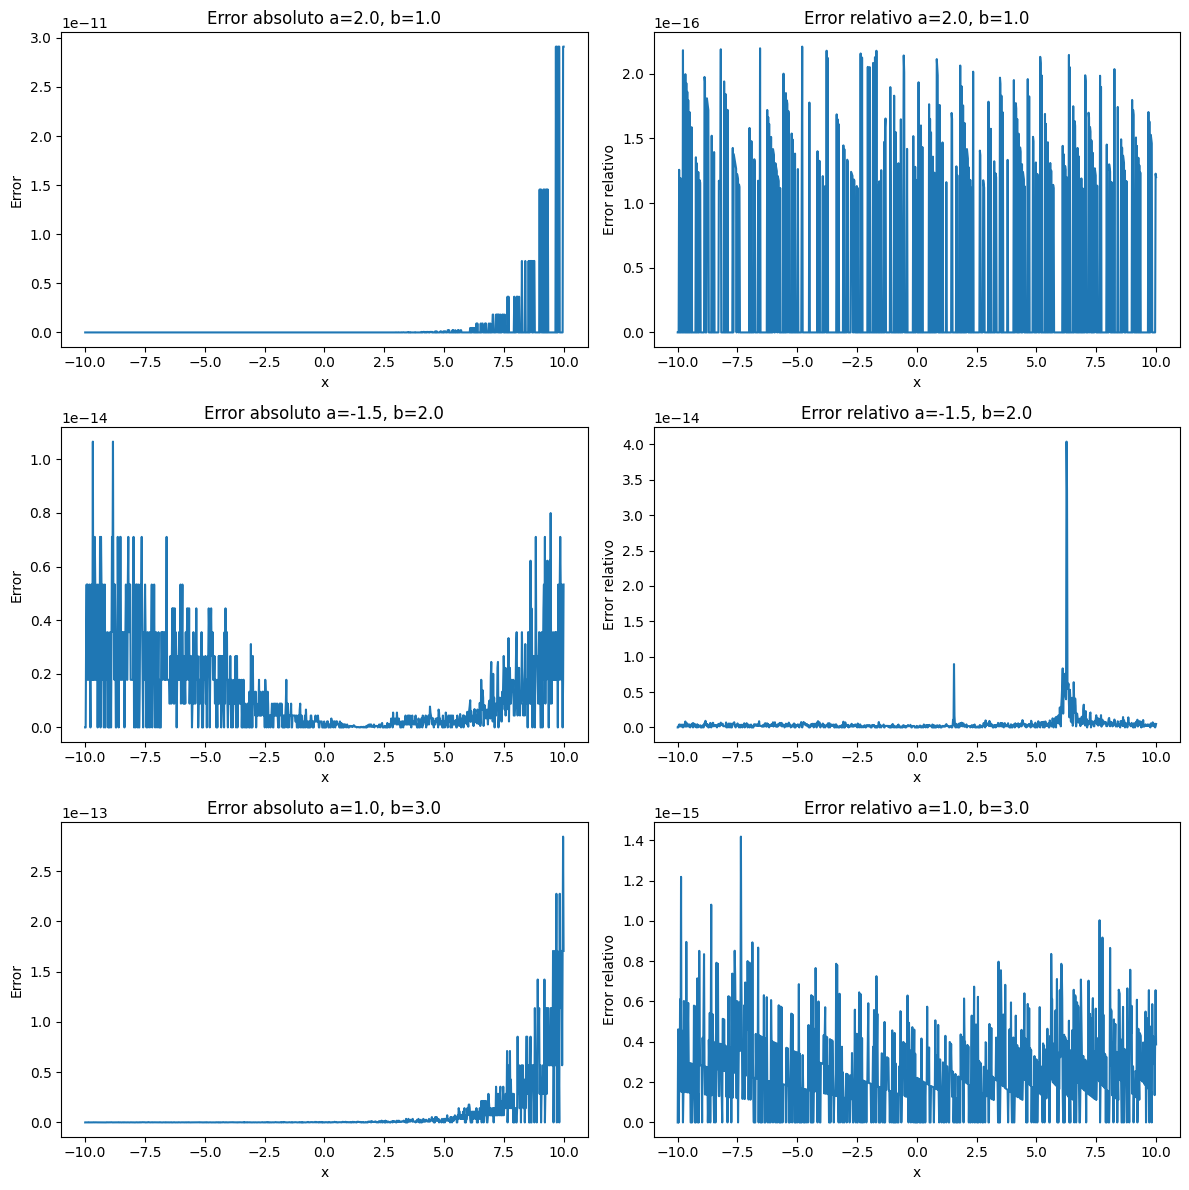

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath
import scipy.special

mpmath.mp.dps = 50  # Precisión alta con mpmath

x_values = np.linspace(-10, 10, 1000)

# Conjuntos de parámetros (a, b) con diferentes características
parametros = [
    (2.0, 1.0),      # a > b, ambos positivos
    (-1.5, 2.0),     # a negativo, b positivo
    (1.0, 3.0),      # a < b, ambos positivos
]

fig, axes = plt.subplots(len(parametros), 2, figsize=(12, 4 * len(parametros)))

for i, (a, b) in enumerate(parametros):
    resultados_mpmath = [mpmath.hyp1f1(a, b, x) for x in x_values]
    resultados_mpmath_float = [float(val.real) for val in resultados_mpmath]
    resultados_scipy = scipy.special.hyp1f1(a, b, x_values)

    error_absoluto = np.abs(np.array(resultados_mpmath_float) - resultados_scipy)
    error_relativo = error_absoluto / (np.abs(resultados_mpmath_float) + 1e-12)

    axes[i, 0].plot(x_values, error_absoluto)
    axes[i, 0].set_title(f'Error absoluto a={a}, b={b}')
    axes[i, 0].set_xlabel('x')
    axes[i, 0].set_ylabel('Error')

    axes[i, 1].plot(x_values, error_relativo)
    axes[i, 1].set_title(f'Error relativo a={a}, b={b}')
    axes[i, 1].set_xlabel('x')
    axes[i, 1].set_ylabel('Error relativo')

plt.tight_layout()
plt.show()


In [32]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading}  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(x) = a1  (x)
f_2(x) = a0  (1 + (i)x^2)
f_3(x) = a1  (x + (i/3)x^3)
f_4(x) = a0  (1 + (2*i)x^2 + (-1/3)x^4)
f_5(x) = a1  (x + (2*i/3)x^3 + (-1/15)x^5)
f_6(x) = a0  (1 + (3*i)x^2 + (-1)x^4 + (-i/15)x^6)
f_7(x) = a1  (x + (i)x^3 + (-1/5)x^5 + (-i/105)x^7)


In [31]:
import sympy as sp

def build_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, N, 2):  
            num = sp.I*(2*s + 1)/2 - sp.I*(2*N + 1)/2   
            den = (s + 2)*(s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, N, 2):  
            num = sp.I*(2*s + 1)/2 - sp.I*(2*N + 1)/2   
            den = (s + 2)*(s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])

    return coeffs, leading

def normalized_coeffs_sympy(N):
    coeffs, leading = build_coeffs_sympy(N)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs], leading

def poly_string_sympy(N, var="x"):
    coeffs_norm, leading = normalized_coeffs_sympy(N)
    leading_name = 'a0' if N % 2 == 0 else 'a1'
    terms = []
    for s, cs in enumerate(coeffs_norm):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(var if s == 1 else "1")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    return (f"f_{N}({var}) = {leading_name}  (" + " + ".join(terms) + ")").replace("I","i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=-1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=-1/4

f_1(x) = a1  (x)
f_2(x) = a0  (1 + (-i)x^2)
f_3(x) = a1  (x + (-i/3)x^3)
f_4(x) = a0  (1 + (-2*i)x^2 + (-1/3)x^4)
f_5(x) = a1  (x + (-2*i/3)x^3 + (-1/15)x^5)
f_6(x) = a0  (1 + (-3*i)x^2 + (-1)x^4 + (i/15)x^6)
f_7(x) = a1  (x + (-i)x^3 + (-1/5)x^5 + (i/105)x^7)


In [30]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading} ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=1, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=1, beta=1/4

f_1(x) = a1 (x)
f_2(x) = a0 (1 + (i/3)x^2)
f_3(x) = a1 (x + (i/6)x^3)
f_4(x) = a0 (1 + (2*i/3)x^2 + (-1/15)x^4)
f_5(x) = a1 (x + (i/3)x^3 + (-1/45)x^5)
f_6(x) = a0 (1 + (i)x^2 + (-1/5)x^4 + (-i/105)x^6)
f_7(x) = a1 (x + (i/2)x^3 + (-1/15)x^5 + (-i/420)x^7)


In [12]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = sp.I * (2*s + 3) / 2 - sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading} ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=1, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=1, beta=1/4

f_1(x) = a1 (x)
f_2(x) = a0 (1 + (-i/3)x^2)
f_3(x) = a1 (x + (i/6)x^3)
f_4(x) = a0 (1 + (-2*i/3)x^2 + (-1/15)x^4)
f_5(x) = a1 (x + (i/3)x^3 + (-1/45)x^5)
f_6(x) = a0 (1 + (-i)x^2 + (-1/5)x^4 + (i/105)x^6)
f_7(x) = a1 (x + (i/2)x^3 + (-1/15)x^5 + (-i/420)x^7)


Polinomios asociados a la ec. hipergeometrica confluente

In [6]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0')  # ya no necesitamos a1

    coeffs = [sp.Integer(0)] * (N + 1)
    coeffs[0] = leading

    a_tr = -2*sp.I*(N*(N-1) + N + sp.Rational(3,4))

    for s in range(0, N):  # paso 1
        num = -(s*(s-1) + s + sp.Rational(3,4) - 2*sp.I*((N*(N-1)) + N+ sp.Rational(3,4)))
        den = (s + 1)
        coeffs[s+1] = sp.simplify((num/den) * coeffs[s])

    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="u"):
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if s == 0:
            terms.append("1")
        else:
            terms.append(f"{sp.simplify(cs)}{var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = a0  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(u) = a0  (1 + -3/4 + 7*i/2u^1)
f_2(u) = a0  (1 + -3/4 + 19*i/2u^1 + -1423/32 - 95*i/8u^2)
f_3(u) = a0  (1 + -3/4 + 39*i/2u^1 + -6063/32 - 195*i/8u^2 + 58679/128 - 76349*i/64u^3)
f_4(u) = a0  (1 + -3/4 + 67*i/2u^1 + -17935/32 - 335*i/8u^2 + 520325/384 - 396305*i/64u^3 + 99445515/2048 + 20307365*i/768u^4)
f_5(u) = a0  (1 + -3/4 + 103*i/2u^1 + -42415/32 - 515*i/8u^2 + 1230245/384 - 1449725*i/64u^3 + 581293515/2048 + 74083265*i/768u^4 + -47785843447/24576 + 31953076223*i/12288u^5)
f_6(u) = a0  (1 + -3/4 + 147*i/2u^1 + -86415/32 - 735*i/8u^2 + 835415/128 - 4225025*i/64u^3 + 2451733515/2048 + 71895495*i/256u^4 + -66672869949/8192 + 68227366809*i/4096u^5 + -11083462026315/65536 - 2804721777305*i/16384u^6)
f_7(u) = a0  (1 + -3/4 + 199*i/2u^1 + -158383/32 - 995*i/8u^2 + 4593317/384 - 10493469*i/64u^3 + 8293088203/2048 + 535451489*i/768u^4 + -3371788269779/122880 + 4807472658139*i/61440u^5 + -3479454044091407/2949120 - 64786419415241*i/81920u^6 + 47991

In [7]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0')  # ya no necesitamos a1

    coeffs = [sp.Integer(0)] * (N + 1)
    coeffs[0] = leading

    a_tr = -2*sp.I*(N*(N-1) + N + sp.Rational(3,4))

    for s in range(1, N):  # paso 1
        num = -(s + sp.Rational(1,4) - 2*sp.I*((N + sp.Rational(1,4))))
        den = (s + 1) * s
        coeffs[s+1] = sp.simplify((num/den) * coeffs[s])

    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="u"):
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if s == 0:
            terms.append("1")
        else:
            terms.append(f"{sp.simplify(cs)}{var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = a0  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(u) = a0  (1)
f_2(u) = a0  (1)
f_3(u) = a0  (1)
f_4(u) = a0  (1)
f_5(u) = a0  (1)
f_6(u) = a0  (1)
f_7(u) = a0  (1)


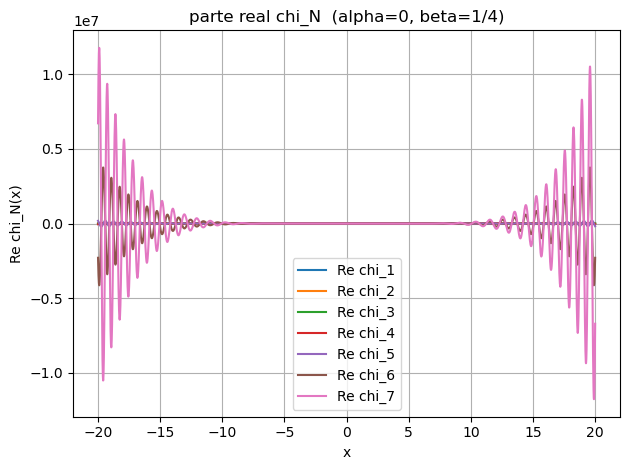

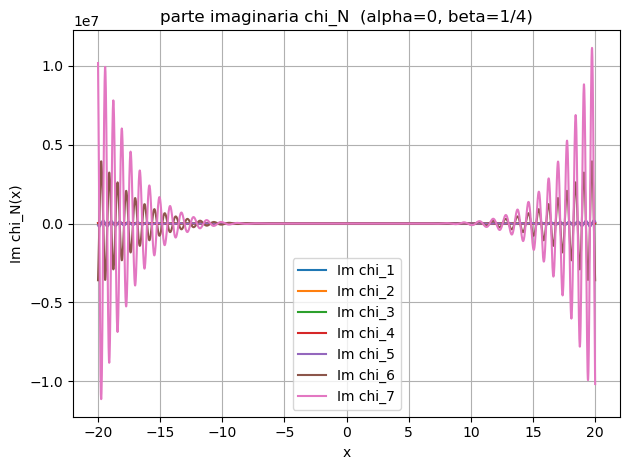

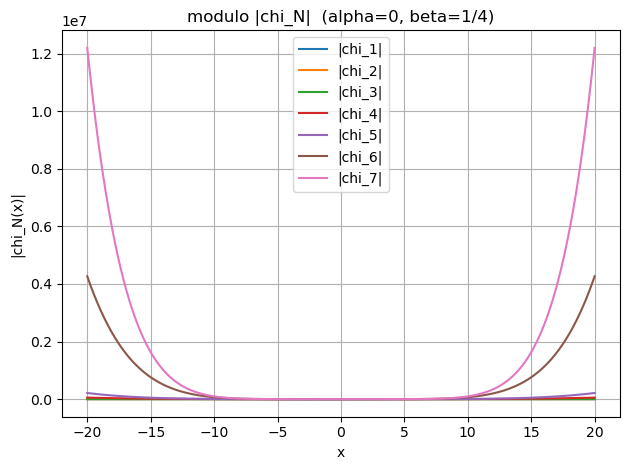

In [41]:


import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

alpha = 0                            
beta = sp.Rational(1, 4)             
Ns = [1, 2, 3, 4, 5, 6, 7]           
x_min, x_max, num = -20, 20, 4000     
save_pngs = True                     


x = sp.symbols('x', real=True)

def build_coeffs_sympy(N, leading=None):
    
    if leading is None:
        leading = sp.Integer(1)  # aqui fijo el lider a 1 para graficar

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  # N par
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  # N impar
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def fN_expr(N):
    # devuelve f_N(x) como polinomio de sympy con coef lider 1
    coeffs = build_coeffs_sympy(N, leading=sp.Integer(1))
    poly = sum(c * x**s for s, c in enumerate(coeffs) if c != 0)
    return sp.simplify(poly)

def chi_expr(N, alpha=0, beta=sp.Rational(1,4)):
    # arma chi usando f_N
    return sp.simplify((x**alpha) * sp.exp(sp.I*beta*x**2) * fN_expr(N))

def chi_funcs(N, alpha=0, beta=sp.Rational(1,4)):
    chi = chi_expr(N, alpha=alpha, beta=beta)
    chi_np = sp.lambdify(x, chi, "numpy")
    def re_fun(xx): return np.real(chi_np(xx))
    def im_fun(xx): return np.imag(chi_np(xx))
    def mod_fun(xx): return np.abs(chi_np(xx))
    return re_fun, im_fun, mod_fun

# malla en x 
xx = np.linspace(x_min, x_max, num)

# parte real 
plt.figure()
for N in Ns:
    re_fun, _, _ = chi_funcs(N, alpha=alpha, beta=beta)
    plt.plot(xx, re_fun(xx), label=f"Re chi_{N}")
plt.title(rf"parte real chi_N  (alpha={alpha}, beta={sp.simplify(beta)})")
plt.xlabel("x")
plt.ylabel("Re chi_N(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
if save_pngs:
    plt.savefig("chi_real.png", dpi=160)
plt.show()

# parte imaginaria 
plt.figure()
for N in Ns:
    _, im_fun, _ = chi_funcs(N, alpha=alpha, beta=beta)
    plt.plot(xx, im_fun(xx), label=f"Im chi_{N}")
plt.title(rf"parte imaginaria chi_N  (alpha={alpha}, beta={sp.simplify(beta)})")
plt.xlabel("x")
plt.ylabel("Im chi_N(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
if save_pngs:
    plt.savefig("chi_imag.png", dpi=160)
plt.show()

# modulo
plt.figure()
for N in Ns:
    _, _, mod_fun = chi_funcs(N, alpha=alpha, beta=beta)
    plt.plot(xx, mod_fun(xx), label=f"|chi_{N}|")
plt.title(rf"modulo |chi_N|  (alpha={alpha}, beta={sp.simplify(beta)})")
plt.xlabel("x")
plt.ylabel("|chi_N(x)|")
plt.legend()
plt.grid(True)
plt.tight_layout()
if save_pngs:
    plt.savefig("chi_mod.png", dpi=160)
plt.show()


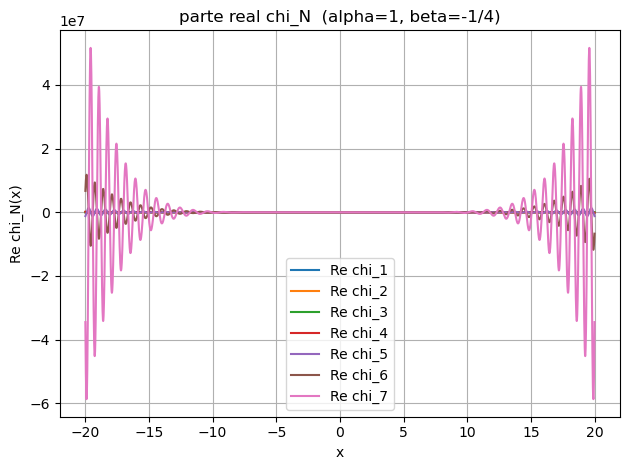

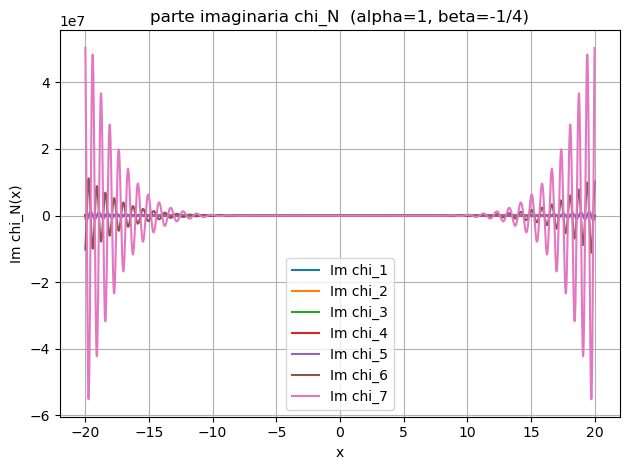

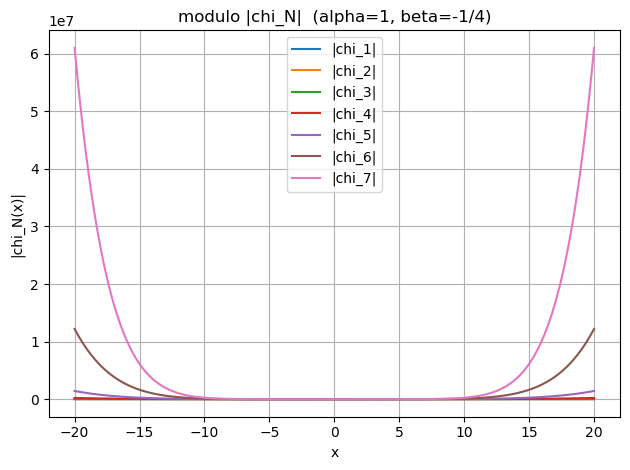

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

alpha = 1                            
beta = -sp.Rational(1, 4)             
Ns = [1, 2, 3, 4, 5, 6, 7]           
x_min, x_max, num = -20, 20, 4000     
save_pngs = True                     


x = sp.symbols('x', real=True)

def build_coeffs_sympy(N, leading=None):
    
    if leading is None:
        leading = sp.Integer(1)  # aqui fijo el lider a 1 para graficar

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  # N par
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = sp.I * (2*s + 3) / 2 - sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  # N impar
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = sp.I * (2*s + 3) / 2 - sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def fN_expr(N):
    
    coeffs = build_coeffs_sympy(N, leading=sp.Integer(1))
    poly = sum(c * x**s for s, c in enumerate(coeffs) if c != 0)
    return sp.simplify(poly)

def chi_expr(N, alpha=0, beta=sp.Rational(1,4)):
    return sp.simplify((x**alpha) * sp.exp(sp.I*beta*x**2) * fN_expr(N))

def chi_funcs(N, alpha=0, beta=sp.Rational(1,4)):
    chi = chi_expr(N, alpha=alpha, beta=beta)
    chi_np = sp.lambdify(x, chi, "numpy")
    def re_fun(xx): return np.real(chi_np(xx))
    def im_fun(xx): return np.imag(chi_np(xx))
    def mod_fun(xx): return np.abs(chi_np(xx))
    return re_fun, im_fun, mod_fun

# malla en x 
xx = np.linspace(x_min, x_max, num)

# parte real 
plt.figure()
for N in Ns:
    re_fun, _, _ = chi_funcs(N, alpha=alpha, beta=beta)
    plt.plot(xx, re_fun(xx), label=f"Re chi_{N}")
plt.title(rf"parte real chi_N  (alpha={alpha}, beta={sp.simplify(beta)})")
plt.xlabel("x")
plt.ylabel("Re chi_N(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
if save_pngs:
    plt.savefig("chi_real.png", dpi=160)
plt.show()

# parte imaginaria 
plt.figure()
for N in Ns:
    _, im_fun, _ = chi_funcs(N, alpha=alpha, beta=beta)
    plt.plot(xx, im_fun(xx), label=f"Im chi_{N}")
plt.title(rf"parte imaginaria chi_N  (alpha={alpha}, beta={sp.simplify(beta)})")
plt.xlabel("x")
plt.ylabel("Im chi_N(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
if save_pngs:
    plt.savefig("chi_imag.png", dpi=160)
plt.show()

# modulo
plt.figure()
for N in Ns:
    _, _, mod_fun = chi_funcs(N, alpha=alpha, beta=beta)
    plt.plot(xx, mod_fun(xx), label=f"|chi_{N}|")
plt.title(rf"modulo |chi_N|  (alpha={alpha}, beta={sp.simplify(beta)})")
plt.xlabel("x")
plt.ylabel("|chi_N(x)|")
plt.legend()
plt.grid(True)
plt.tight_layout()
if save_pngs:
    plt.savefig("chi_mod.png", dpi=160)
plt.show()
